<img src="https://github.com/hernancontigiani/ceia_memorias_especializacion/raw/master/Figures/logoFIUBA.jpg" width="500" align="center">


# Procesamiento de lenguaje natural
## RNN many-to-one

#### Datos
El objecto es utilizar una serie de sucuencias númericas (datos sintéticos) para poner a prueba el uso de las redes RNN. Este ejemplo se inspiró en otro artículo, lo tienen como referencia en el siguiente link:\
[LINK](https://stackabuse.com/solving-sequence-problems-with-lstm-in-keras/)

In [1]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

In [2]:
# Generar datos sintéticos
X = list()
y = list()

# X será una lista de 1 a 45 agrupado de a 3 números consecutivos
# [ [1, 2, 3], [4, 5, 6], ....]
X = [ [x, x+1, x+2] for x in range(1, 46, 3)]

# "y" (target) se obtiene como la suma de cada grupo de 3 números de entrada
y = [sum(x) for x in X]

X = np.array(X).reshape(len(X), 3, 1)   # (n_samples, seq_len, n_features)
y = np.array(y).reshape(-1, 1)

print("datos X:", X)
print("datos y:", y)

datos X: [[[ 1]
  [ 2]
  [ 3]]

 [[ 4]
  [ 5]
  [ 6]]

 [[ 7]
  [ 8]
  [ 9]]

 [[10]
  [11]
  [12]]

 [[13]
  [14]
  [15]]

 [[16]
  [17]
  [18]]

 [[19]
  [20]
  [21]]

 [[22]
  [23]
  [24]]

 [[25]
  [26]
  [27]]

 [[28]
  [29]
  [30]]

 [[31]
  [32]
  [33]]

 [[34]
  [35]
  [36]]

 [[37]
  [38]
  [39]]

 [[40]
  [41]
  [42]]

 [[43]
  [44]
  [45]]]
datos y: [[  6]
 [ 15]
 [ 24]
 [ 33]
 [ 42]
 [ 51]
 [ 60]
 [ 69]
 [ 78]
 [ 87]
 [ 96]
 [105]
 [114]
 [123]
 [132]]


In [3]:
# Train/valid split
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

#Los pasamos a tensores para poder meterlos a la RRN
X_train = torch.tensor(X_train, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.float32)
X_val = torch.tensor(X_val, dtype=torch.float32)
y_val = torch.tensor(y_val, dtype=torch.float32)

In [4]:
y = np.asanyarray(y)
y.shape

(15, 1)

### 2 - Entrenar el modelo

In [5]:
input_shape = X[0].shape
input_shape

(3, 1)

In [6]:
output_shape = 1
output_shape

1

In [7]:
class RNN(nn.Module):
    def __init__(self, input_size=1, hidden_size=64, output_size=1, bidirectional=False):
        super(RNN, self).__init__()
        self.rnn = nn.RNN(input_size, hidden_size, batch_first=True, bidirectional=bidirectional)
        self.fc = nn.Linear(hidden_size * (2 if bidirectional else 1), output_size)
        self.relu = nn.ReLU()

    def forward(self, x):
        out, _ = self.rnn(x)
        out = out[:, -1, :]   # última salida de la secuencia
        out = self.relu(out)
        out = self.fc(out)
        return out

In [8]:

def train_model(model, X_train, y_train, X_val, y_val,
                   epochs=5000, batch_size=5, lr=0.001,
                   patience=60, min_delta=1e-4):
    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    history = {"train_loss": [], "val_loss": []}

    n_samples = X_train.shape[0]
    best_val_loss = float('inf')
    patience_counter = 0
    best_model_state = None

    for epoch in range(epochs):
        model.train()
        perm = torch.randperm(n_samples)
        batch_losses = []

        for i in range(0, n_samples, batch_size):
            idx = perm[i:i+batch_size]
            xb, yb = X_train[idx], y_train[idx]

            optimizer.zero_grad()
            outputs = model(xb)
            loss = criterion(outputs, yb)
            loss.backward()
            optimizer.step()
            batch_losses.append(loss.item())

        # Validación
        model.eval()
        with torch.no_grad():
            val_pred = model(X_val)
            val_loss = criterion(val_pred, y_val).item()

        train_loss_mean = np.mean(batch_losses)
        history["train_loss"].append(train_loss_mean)
        history["val_loss"].append(val_loss)


        if (epoch+1) % 50 == 0:
            print(f"Epoch [{epoch+1}/{epochs}], Train Loss: {train_loss_mean:.4f}, Val Loss: {val_loss:.4f}")


    return history

In [9]:

model1 = RNN()
hist1 = train_model(model1, X_train, y_train, X_val, y_val,epochs=2000)


Epoch [50/2000], Train Loss: 5901.4445, Val Loss: 5702.3979
Epoch [100/2000], Train Loss: 5841.8700, Val Loss: 5351.3779
Epoch [150/2000], Train Loss: 4109.8470, Val Loss: 5030.8921
Epoch [200/2000], Train Loss: 5297.7717, Val Loss: 4731.5649
Epoch [250/2000], Train Loss: 4810.1635, Val Loss: 4452.5269
Epoch [300/2000], Train Loss: 3403.2399, Val Loss: 4197.5308
Epoch [350/2000], Train Loss: 3451.2808, Val Loss: 3959.2214
Epoch [400/2000], Train Loss: 3237.0239, Val Loss: 3736.7947
Epoch [450/2000], Train Loss: 3253.8184, Val Loss: 3466.8406
Epoch [500/2000], Train Loss: 3043.7319, Val Loss: 3207.1970
Epoch [550/2000], Train Loss: 3218.2305, Val Loss: 3004.4856
Epoch [600/2000], Train Loss: 2350.2446, Val Loss: 2807.4724
Epoch [650/2000], Train Loss: 2124.3547, Val Loss: 2615.0750
Epoch [700/2000], Train Loss: 2361.3832, Val Loss: 2436.8064
Epoch [750/2000], Train Loss: 2733.2199, Val Loss: 2268.1416
Epoch [800/2000], Train Loss: 2051.9498, Val Loss: 2113.5100
Epoch [850/2000], Train L

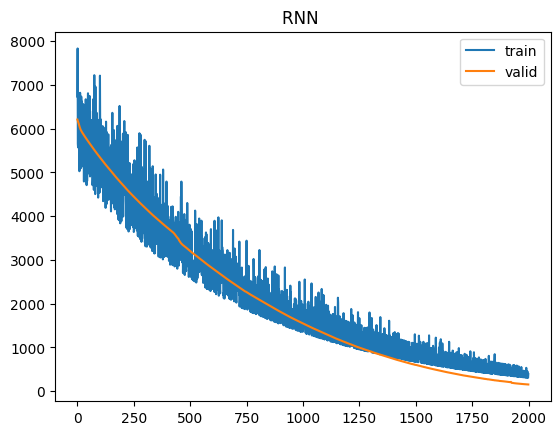

In [13]:
#Curva de entrenamiento
plt.plot(hist1["train_loss"], label="train")
plt.plot(hist1["val_loss"], label="valid")
plt.legend()
plt.title("RNN ")
plt.show()

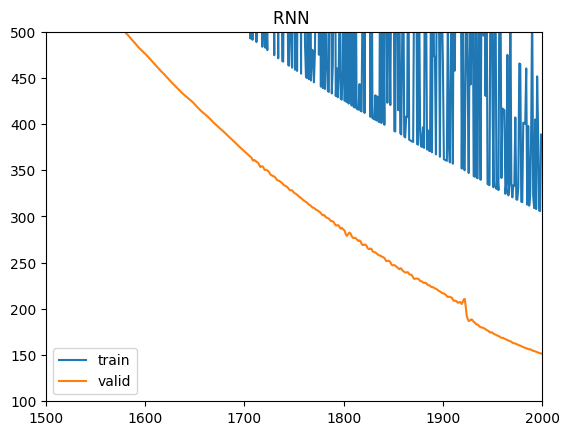

In [24]:
#Curva de entrenamiento
plt.plot(hist1["train_loss"], label="train")
plt.plot(hist1["val_loss"], label="valid")
plt.ylim(100,500)
plt.xlim(1500,2000)
plt.legend()
plt.title("RNN ")
plt.show()

In [14]:

# Ensayo
x_test = np.array([[50, 51, 52]]).reshape((1, 3, 1))
x_test = torch.tensor(x_test, dtype=torch.float32)
y_test = torch.tensor([[sum([50, 51, 52])]], dtype=torch.float32)

with torch.no_grad():
    y_hat1 = model1(x_test).item()

print("Modelo Simple y_test:", y_test.item(), "y_hat:", y_hat1)

Modelo Simple y_test: 153.0 y_hat: 85.16437530517578


### 3 - Bidirectional RNN (BRNN)

In [15]:
# En esta oportunidad se utilizará Bidirectional, dentro se especifica
# que lo que se desea hacer bidireccional es una capa LSTM

# En el summary se puede observar que la cantidad de parámetros
# de nuestor nueva capa LSTM bidireccional es el doble que la anterior

model2 = RNN(bidirectional=True)

hist2 = train_model(model2, X_train, y_train, X_val, y_val,epochs=1800)

with torch.no_grad():
    y_hat2 = model2(x_test).item()

print("y_test:", y_test.item())
print("y_hat (bidirectional):", y_hat2)

Epoch [50/1800], Train Loss: 6253.7898, Val Loss: 5174.9170
Epoch [100/1800], Train Loss: 3580.8856, Val Loss: 4397.3081
Epoch [150/1800], Train Loss: 3442.8554, Val Loss: 3774.6719
Epoch [200/1800], Train Loss: 2663.5712, Val Loss: 3241.7932
Epoch [250/1800], Train Loss: 3175.6814, Val Loss: 2679.6013
Epoch [300/1800], Train Loss: 1945.0624, Val Loss: 2231.5310
Epoch [350/1800], Train Loss: 2372.3284, Val Loss: 1872.6425
Epoch [400/1800], Train Loss: 1453.5170, Val Loss: 1554.1635
Epoch [450/1800], Train Loss: 1653.0245, Val Loss: 1269.5304
Epoch [500/1800], Train Loss: 1566.6922, Val Loss: 1025.6552
Epoch [550/1800], Train Loss: 853.4135, Val Loss: 821.3155
Epoch [600/1800], Train Loss: 734.7479, Val Loss: 657.6610
Epoch [650/1800], Train Loss: 917.3641, Val Loss: 518.0617
Epoch [700/1800], Train Loss: 708.4436, Val Loss: 400.6445
Epoch [750/1800], Train Loss: 466.2998, Val Loss: 306.6769
Epoch [800/1800], Train Loss: 398.3899, Val Loss: 228.8806
Epoch [850/1800], Train Loss: 357.044

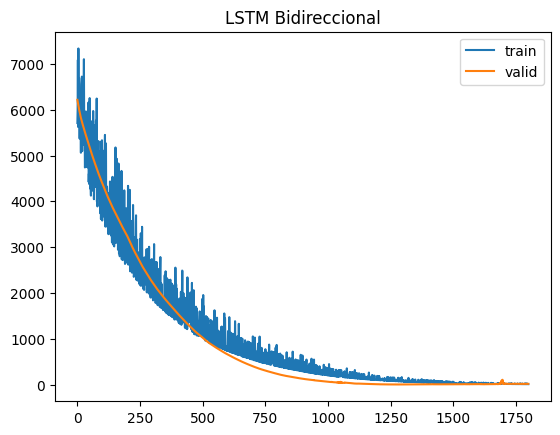

In [17]:
plt.plot(hist2["train_loss"], label="train")
plt.plot(hist2["val_loss"], label="valid")
plt.legend()
plt.title("LSTM Bidireccional")
plt.show()

In [18]:
# Ensayo
x_test = np.array([[50, 51, 52]]).reshape((1, 3, 1))
x_test = torch.tensor(x_test, dtype=torch.float32)
y_test = torch.tensor([[sum([50, 51, 52])]], dtype=torch.float32)

with torch.no_grad():
    y_hat2 = model2(x_test).item()

print("Modelo Bidireccional y_test:", y_test.item(), "y_hat:", y_hat2)

Modelo Bidireccional y_test: 153.0 y_hat: 121.31742858886719


### 4 - Conclusión
Implementar un modelo bidireccional basado en RNN es muy sencillo. Más allá de que esta tarea podria resolverse de otras maneras, les queda nota de como definir y entrenar estos tipos de redes neuronales recurrentes con y sin bidireccionalidad.